# 🧠 **AI Fundamentals: Skin Lesion Image Classification**

| **About** | **Details** |
|-----------|-------------|
| **Workshop** | FARADISA Workshop 2026 - Day 1 |
| **Topic** | AI Fundamentals & Image Classification |
| **Case Study** | Skin Lesion Detection (Normal vs Abnormal) |
| **Platform** | Google Colab |

## 📋 Notebook Structure

1. **Setup Environment** - Install libraries and download dataset
2. **Data Preparation** - Load and explore the dataset
3. **Data Preprocessing** - Image transformations and augmentation
4. **Model Architecture** - Build EfficientNet-B0 model
5. **Model Training** - Train and validate the model
6. **Model Evaluation** - Evaluate on test set

> 💡 **Note:** The goal of this notebook is not to achieve the highest accuracy, but to clearly demonstrate the fundamental concepts and workflow of building an AI model.



# **1️⃣ Setup Environment**

### 1.1 Install Dependencies

Make sure required libraries are installed.

In [1]:
# Install dependencies
!pip install torch torchvision efficientnet_pytorch pandas matplotlib seaborn scikit-learn tqdm pillow -q

  Preparing metadata (setup.py) ... done


### 1.2 Import Libraries

In [2]:
# Basic libraries
import os                                             # For file and folder operations
import random                                         # For random number generation
import time                                           # For measuring training time

# Data processing libraries
import numpy as np                                    # Array/matrix operations
import pandas as pd                                   # Read CSV files
from PIL import Image                                 # Open images

# Visualization libraries
import matplotlib.pyplot as plt                       # Create charts
import seaborn as sns                                 # Create heatmaps
from tqdm import tqdm                                 # Progress bar

# PyTorch - Deep Learning Framework
import torch                                          # Main library
import torch.nn as nn                                 # Create neural networks
import torch.optim as optim                           # Optimizers (Adam, SGD, etc.)
from torch.utils.data import Dataset, DataLoader      # Load data
from torchvision import transforms                    # Image augmentation

# Library for pretrained models
from efficientnet_pytorch import EfficientNet         # EfficientNet Model

# Sklearn - Calculate metrics
from sklearn.model_selection import train_test_split  # Data splitting
from sklearn.metrics import (
    accuracy_score,                                   # Standard accuracy
    balanced_accuracy_score,                          # Balanced accuracy (important for imbalanced data)
    precision_score,                                  # Precision
    recall_score,                                     # Recall/Sensitivity
    f1_score,                                         # F1-Score
    confusion_matrix,                                 # Confusion Matrix
    classification_report                             # Full report
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### 1.3 Configuration

In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'💻 Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Set Working Directory
LOCAL_DIR = 'workshop-data'
BASE_DIR = os.path.join(LOCAL_DIR, 'day-1')
TRAIN_DIR = os.path.join(BASE_DIR, 'data/train')
TEST_DIR = os.path.join(BASE_DIR, 'data/test')
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'\n📁 Working Directory:')
print(f'Train data: {TRAIN_DIR}')
print(f'Test data: {TEST_DIR}')
print(f"Output folder: {OUTPUT_DIR}/")

💻 Device: cpu

📁 Working Directory:
Train data: workshop-data/day-1/data/train
Test data: workshop-data/day-1/data/test
Output folder: output/


# **2️⃣ Data Understanding**

In this section we will:
- Load dataset
- Understand dataset structure
- Explore the data
- Analyze class distribution

### 2.1 Load Dataset

In [4]:
# Download dataset from GitHub

# GitHub repository settings
GITHUB_REPO_URL = 'https://github.com/YARSIAICenter/faradisa-workshop-2026'
DATA_FOLDER = 'day-1/data'  # Data folder for Day 1

if not os.path.exists(LOCAL_DIR):
    print('Downloading dataset...')
    !git clone --filter=blob:none --sparse {GITHUB_REPO_URL} {LOCAL_DIR}
    %cd {LOCAL_DIR}
    !git sparse-checkout set {DATA_FOLDER}
    %cd ..
    print('✅ Download complete!')
else:
    print(f'✅ Data already exists in folder {LOCAL_DIR}/')

Cloning into 'workshop-data'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 21 (delta 3), reused 18 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 38.43 KiB | 19.21 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/workshop-data
remote: Enumerating objects: 952, done.
remote: Counting objects: 100% (952/952), done.
remote: Compressing objects: 100% (952/952), done.
remote: Total 952 (delta 0), reused 952 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (952/952), 383.94 MiB | 19.00 MiB/s, done.
Updating files: 100% (952/952), done.
/content
✅ Download complete!


### 2.2 Understanding Dataset Structure

In [5]:
# Read labels.csv file
train_df = pd.read_csv(os.path.join(TRAIN_DIR, 'labels.csv'))
test_df = pd.read_csv(os.path.join(TEST_DIR, 'labels.csv'))

print('=== DATASET INFO ===')
print(f'Training samples: {len(train_df)}')
print(f'Test samples: {len(test_df)}')
print(f'Columns: {list(train_df.columns)}')

print(f'\n=== Sample Data ===')
train_df.head()

=== DATASET INFO ===
Training samples: 700
Test samples: 250
Columns: ['filename', 'label']

=== Sample Data ===


,filename,label
0,ISIC_0066645.jpg,0
1,ISIC_0055567.jpg,1
2,ISIC_0000303.jpg,1
3,ISIC_0072179.jpg,0
4,ISIC_0055311.jpg,1


### 2.3 Class Distribution Analysis

=== Class Percentages ===
Normal: 35.7%
Abnormal: 64.3%

=== Class Distribution ===


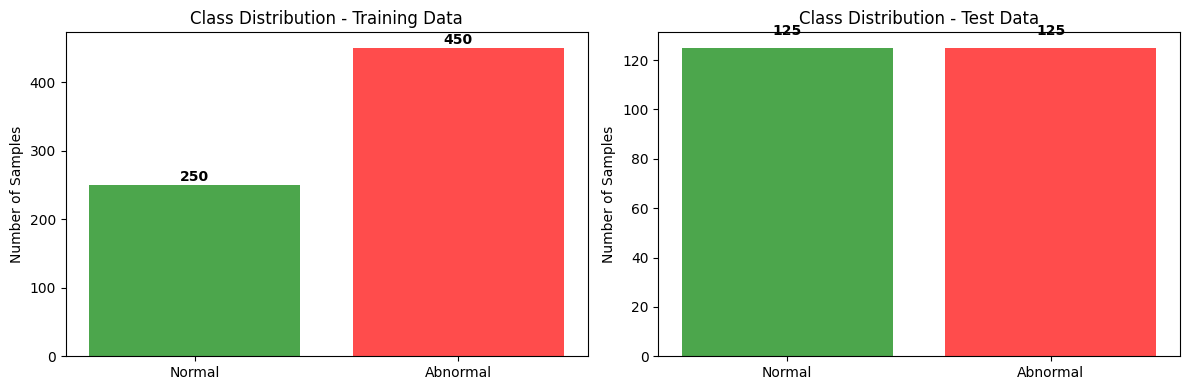

In [6]:
# Class configuration
NUM_CLASSES = 2
CLASS_NAMES = ['Normal', 'Abnormal']

# Calculate class distribution
train_dist = train_df['label'].value_counts().sort_index()
test_dist = test_df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training distribution
axes[0].bar(CLASS_NAMES, train_dist.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Class Distribution - Training Data')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(train_dist.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Test distribution
axes[1].bar(CLASS_NAMES, test_dist.values, color=['green', 'red'], alpha=0.7)
axes[1].set_title('Class Distribution - Test Data')
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate(test_dist.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Class percentages
print('=== Class Percentages ===')
for i, name in enumerate(CLASS_NAMES):
    pct = train_dist.values[i] / len(train_df) * 100
    print(f'{name}: {pct:.1f}%')

print('\n=== Class Distribution ===')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

### 2.4 Sample Image Visualization

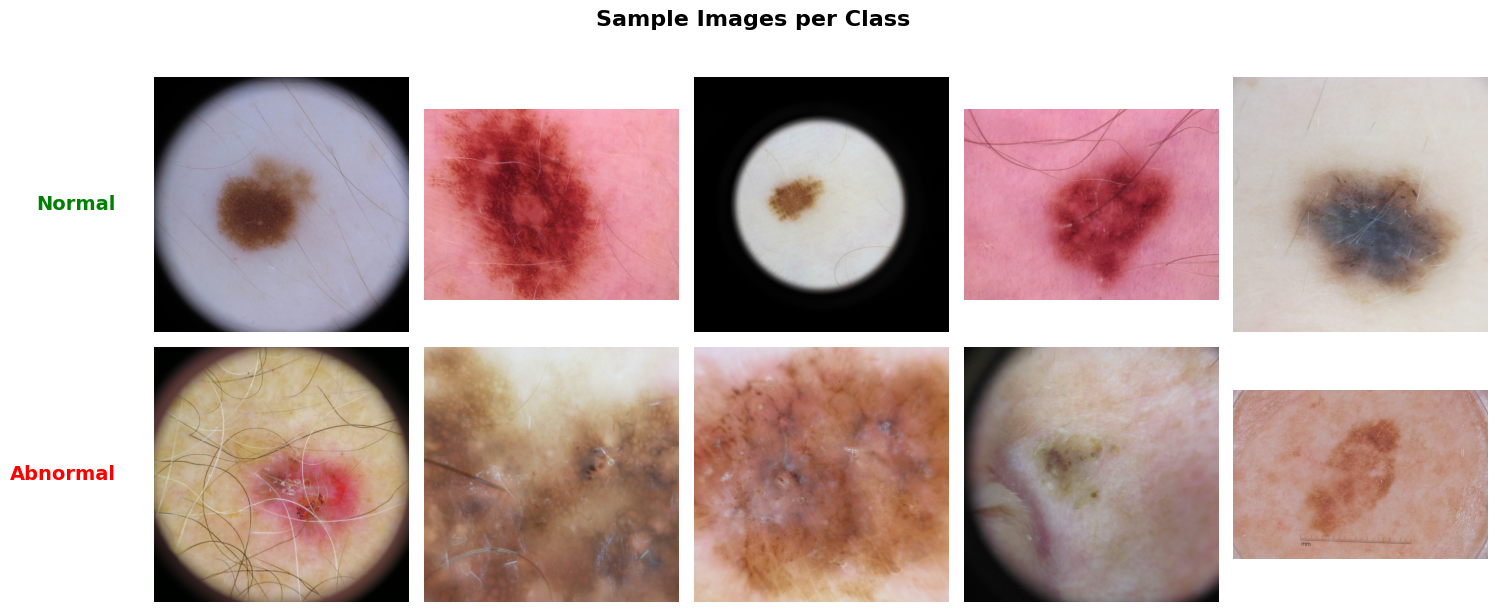

In [7]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for class_idx, class_name in enumerate(CLASS_NAMES):
    # Filter data by class
    class_samples = train_df[train_df['label'] == class_idx].sample(5, random_state=SEED)

    for i, (_, row) in enumerate(class_samples.iterrows()):
        img_path = os.path.join(TRAIN_DIR, 'images', row['filename'])
        img = Image.open(img_path)

        axes[class_idx, i].imshow(img)
        axes[class_idx, i].axis('off')

# Add row labels (class names) on the left side
for class_idx, class_name in enumerate(CLASS_NAMES):
    color = 'green' if class_idx == 0 else 'red'
    axes[class_idx, 0].text(-0.15, 0.5, class_name, transform=axes[class_idx, 0].transAxes,
                            fontsize=14, fontweight='bold', color=color,
                            verticalalignment='center', horizontalalignment='right')

plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

# **3️⃣ Data Preprocessing**

Preprocessing is an important step to prepare the data before training:

* **Resize:** Adjusting the image dimensions
* **Normalization:** Normalizing pixel values
* **Augmentation:** Increasing data variability to prevent overfitting

### 3.1 Create Dataset Class

Custom PyTorch Dataset for loading skin lesion images.

> Folder structure:

    data_dir/
        labels.csv
        images/
            image1.jpg
            image2.jpg

In [8]:
class SkinLesionDataset(Dataset):
    def __init__(self, data_dir, transform, indices=None):
        # Read CSV
        csv_path = os.path.join(data_dir, 'labels.csv')
        df = pd.read_csv(csv_path)

        # Create a list of (path, label)
        self.samples = []
        for _, row in df.iterrows():
            img_path = os.path.join(data_dir, 'images', row['filename'])
            self.samples.append((img_path, int(row['label'])))

        # Filter by indices if provided
        if indices is not None:
            self.samples = [self.samples[i] for i in indices]

        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        return image, label

print('✅ Dataset class created!')

✅ Dataset class created!


### 3.2 Define Preprocessing Pipeline

In [9]:
# Set image size
IMAGE_SIZE = 224                                # EfficientNet-B0 requires 224x224 pixel images

# Transform for training (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),              # Resize to 256x256
    transforms.RandomCrop(IMAGE_SIZE),          # Random crop to 224x224
    transforms.RandomHorizontalFlip(p=0.5),     # Horizontal flip 50%
    transforms.RandomVerticalFlip(p=0.5),       # Vertical flip 50%
    transforms.RandomRotation(20),              # Rotate from -20 to +20 degrees
    transforms.ColorJitter(                     # Color variation
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),                      # Convert to tensor
    transforms.Normalize(                       # Normalization (ImageNet stats)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transform for VALIDATION/TEST (without augmentation)
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),          # Center crop
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('✅ Transform pipeline successfully created!')
print('  - Training: with augmentation')
print('  - Validation/Test: without augmentation')

✅ Transform pipeline successfully created!
  - Training: with augmentation
  - Validation/Test: without augmentation


### 3.3 Visualization of Augmentation Effect

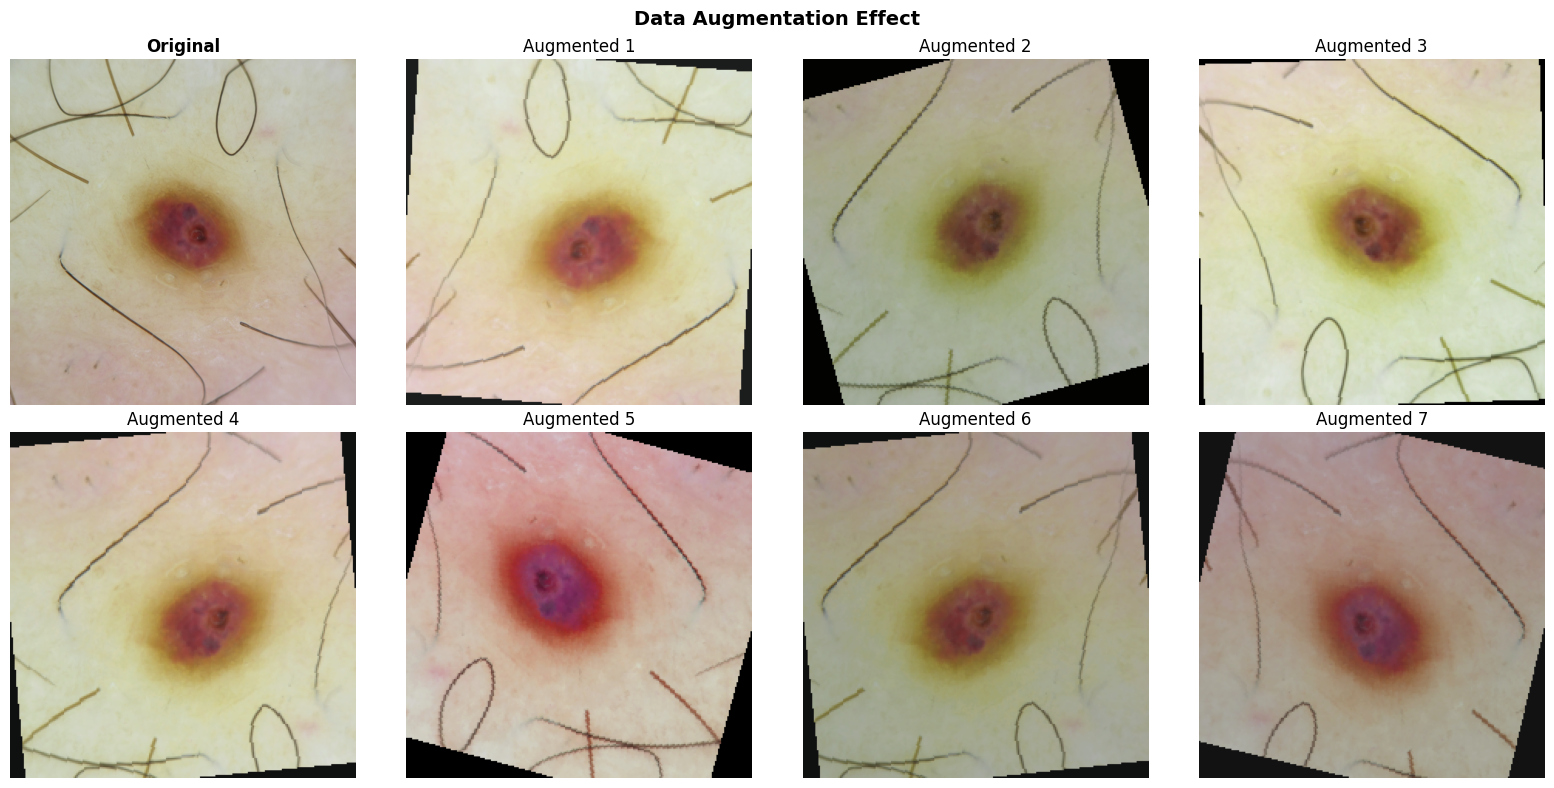

In [10]:
# Get one sample image
sample_path = os.path.join(TRAIN_DIR, 'images', train_df.iloc[0]['filename'])
original_img = Image.open(sample_path)

# Display the original and several augmentations
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(original_img)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

# Augmented versions
for i in range(1, 8):
    row, col = i // 4, i % 4
    augmented = train_transform(original_img)

    # Denormalize for visualization
    img_display = augmented.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    axes[row, col].imshow(img_display)
    axes[row, col].set_title(f'Augmented {i}')
    axes[row, col].axis('off')

plt.suptitle('Data Augmentation Effect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmentation_examples.png'), dpi=150)
plt.show()

### 3.4 Make DataLoader

In [11]:
# Configuration
BATCH_SIZE = 32      # Number of images per batch (32 is standard)
TRAIN_RATIO = 0.85   # 85% of data for training, 15% for validation

# Split data into train and validation
all_labels = train_df['label'].tolist()
train_indices, val_indices = train_test_split(
    range(len(train_df)),
    train_size=TRAIN_RATIO,
    stratify=all_labels,  # Maintain class proportions
    random_state=SEED
)

# Create Dataset
train_dataset = SkinLesionDataset(TRAIN_DIR, train_transform, train_indices)
val_dataset = SkinLesionDataset(TRAIN_DIR, val_transform, val_indices)
test_dataset = SkinLesionDataset(TEST_DIR, val_transform)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available(), generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print('=== DataLoader ===')
print(f'Training: {len(train_dataset)} samples, {len(train_loader)} batcheses')
print(f'Validation: {len(val_dataset)} samples, {len(val_loader)} batcheses')
print(f'Test: {len(test_dataset)} samples, {len(test_loader)} batcheses')

=== DataLoader ===
Training: 595 samples, 19 batcheses
Validation: 105 samples, 4 batcheses
Test: 250 samples, 8 batcheses


# **4️⃣ Model Architecture**

We will use a pre-trained model, EfficientNet-B0, an efficient CNN model with high performance.

> **What is Transfer Learning?**

Instead of training the model from scratch, we use a model that has already been trained on ImageNet (millions of images), and then fine-tune it for our specific task.

In [12]:
# Load pretrained model
model = EfficientNet.from_pretrained('efficientnet-b0')

# Replace the final layer for 2 classes
model._fc = nn.Linear(model._fc.in_features, NUM_CLASSES)

# Move to device
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('\n=== ⚙️ Model Architecture ⚙️ ===')
print(f'Model: EfficientNet-B0')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Output classes: {NUM_CLASSES}')

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 218MB/s]

Loaded pretrained weights for efficientnet-b0

=== ⚙️ Model Architecture ⚙️ ===
Model: EfficientNet-B0
Total parameters: 4,010,110
Trainable parameters: 4,010,110
Output classes: 2


# **5️⃣ Model Training**

> **Training Components:**
* **Loss Function:** CrossEntropyLoss – measures how incorrect the model's predictions are
* **Optimizer:** Adam – an algorithm for updating the model weights
* **Scheduler:** CosineAnnealingLR – gradually decreases the learning rate

### 5.1 Training Setup

In [13]:
# Configuration
LEARNING_RATE = 3e-4    # How fast the model learns (0.0003)
WEIGHT_DECAY = 5e-4     # Regularization to prevent overfitting
EPOCHS = 3              # Number of times the model sees the entire dataset

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('Training setup:')
print(f'  Loss: CrossEntropyLoss')
print(f'  Optimizer: Adam (lr={LEARNING_RATE})')
print(f'  Scheduler: CosineAnnealingLR')

Training setup:
  Loss: CrossEntropyLoss
  Optimizer: Adam (lr=0.0003)
  Scheduler: CosineAnnealingLR


### 5.2 Training Loop

In [14]:
# History for tracking
history = {'train_loss': [], 'val_loss': [], 'val_bacc': []}
best_val_bacc = 0.0
best_epoch = 0

print('=' * 50)
print('🚀 TRAINING STARTED')
print('=' * 50)

start_time = time.time()

for epoch in range(EPOCHS):
    # === TRAINING ==
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=True):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)

    # === VALIDATION ==
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_dataset)
    val_bacc = balanced_accuracy_score(all_labels, all_preds) * 100

    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_bacc'].append(val_bacc)

    # Save the best model
    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_model.pth'))
        print(f'Epoch {epoch+1}: Loss={train_loss:.4f}/{val_loss:.4f}, BACC={val_bacc:.2f}% [⭐ BEST]')
    else:
        print(f'Epoch {epoch+1}: Loss={train_loss:.4f}/{val_loss:.4f}, BACC={val_bacc:.2f}%')
    print()

total_time = time.time() - start_time
print('=' * 50)
print(f'✅ Training completed in {total_time/60:.1f} minutes')
print(f'⭐ Best epoch: {best_epoch}, Best BACC: {best_val_bacc:.2f}%')

🚀 TRAINING STARTED


Epoch 1/3: 100%|██████████| 19/19 [03:43<00:00, 11.78s/it]


Epoch 1: Loss=0.5701/0.5172, BACC=73.37% [⭐ BEST]



Epoch 2/3: 100%|██████████| 19/19 [03:43<00:00, 11.74s/it]


Epoch 2: Loss=0.4269/0.4703, BACC=74.47% [⭐ BEST]



Epoch 3/3: 100%|██████████| 19/19 [03:47<00:00, 11.95s/it]


Epoch 3: Loss=0.3894/0.4491, BACC=76.53% [⭐ BEST]

✅ Training completed in 11.7 minutes
⭐ Best epoch: 3, Best BACC: 76.53%


### 5.3 Training Visualization

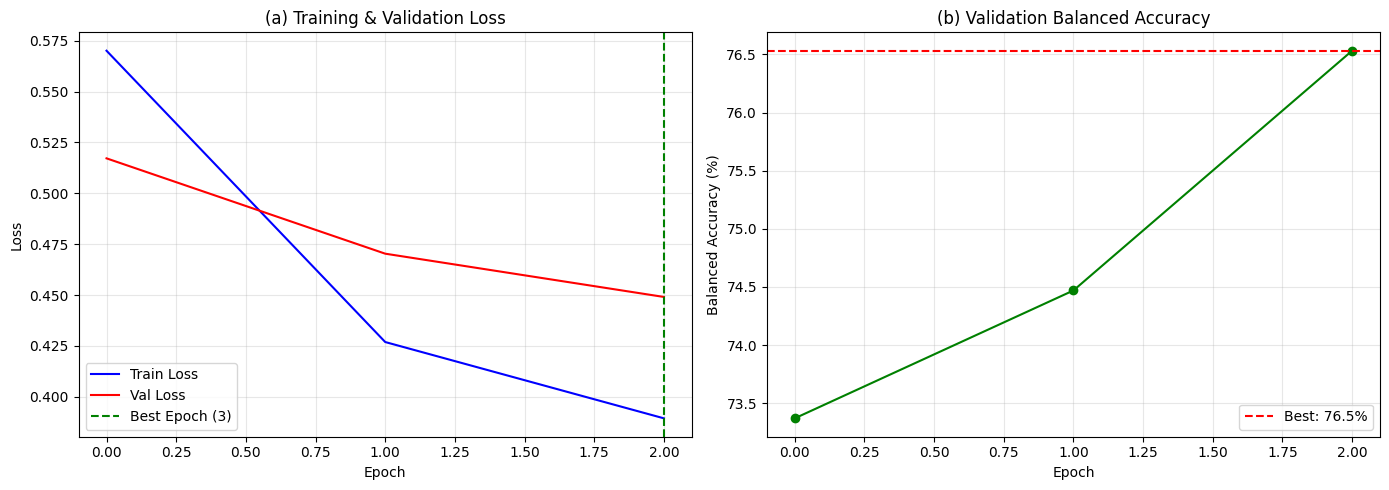

📊 Figure Explanation:
(a) Training & Validation Loss:
    - Blue line: Training loss (how well model fits training data)
    - Red line: Validation loss (how well model generalizes)
    - If val_loss >> train_loss: model is OVERFITTING
    - Green dashed line: Best epoch based on validation metric

(b) Validation Balanced Accuracy:
    - Shows model performance on validation set each epoch
    - Balanced Accuracy: average of recall for each class
    - Important for imbalanced datasets (like medical data)
    - Red dashed line: Best accuracy achieved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss (a)
axes[0].plot(history['train_loss'], 'b-', label='Train Loss')
axes[0].plot(history['val_loss'], 'r-', label='Val Loss')
axes[0].axvline(x=best_epoch-1, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('(a) Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy (b)
axes[1].plot(history['val_bacc'], 'g-o')
axes[1].axhline(y=best_val_bacc, color='r', linestyle='--', label=f'Best: {best_val_bacc:.1f}%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Balanced Accuracy (%)')
axes[1].set_title('(b) Validation Balanced Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150)
plt.show()

# Figure explanation
print('📊 Figure Explanation:')
print('='*60)
print('(a) Training & Validation Loss:')
print('    - Blue line: Training loss (how well model fits training data)')
print('    - Red line: Validation loss (how well model generalizes)')
print('    - If val_loss >> train_loss: model is OVERFITTING')
print('    - Green dashed line: Best epoch based on validation metric')
print()
print('(b) Validation Balanced Accuracy:')
print('    - Shows model performance on validation set each epoch')
print('    - Balanced Accuracy: average of recall for each class')
print('    - Important for imbalanced datasets (like medical data)')
print('    - Red dashed line: Best accuracy achieved')
print('='*60)

# **6️⃣ Model Evaluation**

Model evaluation is performed using a separate test set that the model has never seen during training.

> **Evaluation Metrics:**


- **Accuracy**: Percentage of correct predictions
- **Balanced Accuracy**: Average recall across classes (important for imbalanced data)
- **Precision**: Among the samples predicted as positive, how many are actually positive
- **Recall**: Among the samples that are actually positive, how many are correctly detected
- **F1-Score**: Harmonic mean of precision and recall

### 6.1 Load Best Model and Evaluate

In [16]:
# Load best model
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth')))
model.eval()

# Evaluasi pada test set
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print('\n✅ Test set evaluation complete!')

Evaluating: 100%|██████████| 8/8 [00:24<00:00,  3.10s/it]


✅ Test set evaluation complete!


### 6.2 Calculate Metrics

In [17]:
# Calculate all the evaluation metrics
acc = accuracy_score(all_labels, all_preds) * 100
bacc = balanced_accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='weighted') * 100
recall = recall_score(all_labels, all_preds, average='weighted') * 100
f1 = f1_score(all_labels, all_preds, average='weighted') * 100

print('=' * 50)
print('📋 EVALUATION RESULTS - TEST SET')
print('=' * 50)
print(f'Accuracy          : {acc:.2f}%')
print(f'Balanced Accuracy : {bacc:.2f}%')
print(f'Precision         : {precision:.2f}%')
print(f'Recall            : {recall:.2f}%')
print(f'F1-Score          : {f1:.2f}%')
print('=' * 50)

📋 EVALUATION RESULTS - TEST SET
Accuracy          : 34.40%
Balanced Accuracy : 34.40%
Precision         : 27.84%
Recall            : 34.40%
F1-Score          : 29.16%


### 6.3 Confusion Matrix

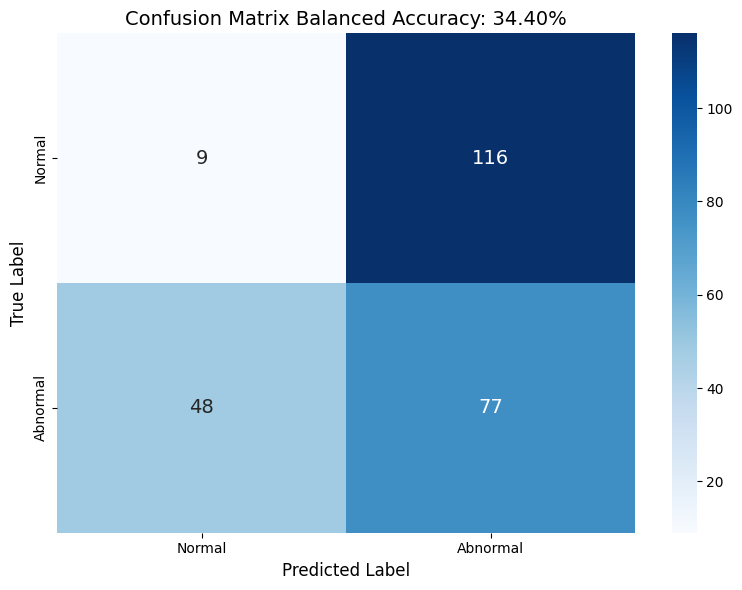

Confusion Matrix Interpretation:
  True Negative (Correct Normal)  : 9
  False Positive (Incorrect Normal) : 116
  False Negative (Incorrect Abnormal): 48
  True Positive (Correct Abnormal): 77


In [18]:
# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={'size': 14}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix Balanced Accuracy: {bacc:.2f}%', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# Interpretation
print('Confusion Matrix Interpretation:')
print(f'  True Negative (Correct Normal)  : {cm[0,0]}')
print(f'  False Positive (Incorrect Normal) : {cm[0,1]}')
print(f'  False Negative (Incorrect Abnormal): {cm[1,0]}')
print(f'  True Positive (Correct Abnormal): {cm[1,1]}')

### 6.4 Classification Report

In [19]:
# Show classification report

print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Classification Report:
              precision    recall  f1-score   support

      Normal       0.16      0.07      0.10       125
    Abnormal       0.40      0.62      0.48       125

    accuracy                           0.34       250
   macro avg       0.28      0.34      0.29       250
weighted avg       0.28      0.34      0.29       250



# **7️⃣ Summary**

This notebook covered the complete machine learning pipeline for medical image classification.

In [20]:
print('=' * 60)
print('📝 AI FUNDAMENTALS HANDS-ON SUMMARY')
print('=' * 60)
print()
print('1. DATA PREPARATION')
print(f'   - Training data: {len(train_df)} sampel')
print(f'   - Test data: {len(test_df)} sampel')
print()
print('2. DATA PREPROCESSING')
print(f'   - Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'   - Augmentation: flip, rotation, color jitter')
print(f'   - Train/Val split: {int(TRAIN_RATIO*100)}%/{int((1-TRAIN_RATIO)*100)}%')
print()
print('3. MODEL ARCHITECTURE')
print(f'   - Model: EfficientNet-B0 (pretrained)')
print(f'   - Output: {NUM_CLASSES} classes ({CLASS_NAMES})')
print()
print('4. MODEL TRAINING')
print(f'   - Epochs: {EPOCHS}')
print(f'   - Best epoch: {best_epoch}')
print(f'   - Best val BACC: {best_val_bacc:.2f}%')
print()
print('5. MODEL EVALUATION')
print(f'   - Test Accuracy: {acc:.2f}%')
print(f'   - Test Balanced Accuracy: {bacc:.2f}%')
print(f'   - Test F1-Score: {f1:.2f}%')
print()
print('=' * 60)
print('Model saved at:', os.path.join(OUTPUT_DIR, 'best_model.pth'))
print('=' * 60)

📝 AI FUNDAMENTALS HANDS-ON SUMMARY

1. DATA PREPARATION
   - Training data: 700 sampel
   - Test data: 250 sampel

2. DATA PREPROCESSING
   - Image size: 224x224
   - Augmentation: flip, rotation, color jitter
   - Train/Val split: 85%/15%

3. MODEL ARCHITECTURE
   - Model: EfficientNet-B0 (pretrained)
   - Output: 2 classes (['Normal', 'Abnormal'])

4. MODEL TRAINING
   - Epochs: 3
   - Best epoch: 3
   - Best val BACC: 76.53%

5. MODEL EVALUATION
   - Test Accuracy: 34.40%
   - Test Balanced Accuracy: 34.40%
   - Test F1-Score: 29.16%

Model saved at: output/best_model.pth
